In [14]:
import torch
from roboflow import Roboflow
import dotenv
import os
import yaml
from pathlib import Path
from ultralytics import YOLO
from IPython.display import Image, display
import glob

## Check GPU

In [2]:
print(f"PyTorch version  : {torch.__version__}")
print(f"CUDA available   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU              : {torch.cuda.get_device_name(0)}")
    print(f"VRAM             : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
else:
    print("WARNING: CUDA not available! Training will be very slow on CPU.")

PyTorch version  : 2.5.1+cu121
CUDA available   : True
GPU              : NVIDIA GeForce GTX 1650 with Max-Q Design
VRAM             : 4.0 GB


## Init Configs

In [19]:
dotenv.load_dotenv()

# ── Roboflow ──────────────────────────────────
API_KEY      = os.getenv("API_KEY")       # Your Roboflow API key
PROJECT_ID   = os.getenv("PROJECT_ID") # Your Roboflow project ID
VERSION      = 1                              # Dataset version number

# ── Training ──────────────────────────────────
MODEL        = os.getenv("MODEL_NAME")  # yolov8n=fastest, yolov8s=balanced ✅, yolov8m=best accuracy
EPOCHS       = 100
IMAGE_SIZE   = 640
BATCH_SIZE   = 8             # Reduce to 4 if you get CUDA out-of-memory
PATIENCE     = 20            # Early stopping: stops if no improvement after N epochs

# ── Output ────────────────────────────────────
PROJECT_DIR  = r"C:\Users\KAKA\repos\companies\cbi\yolo-compvis-project"
PROJECT_NAME = os.getenv("PROJECT_NAME")
RUN_NAME     = "run1"

# Full paths (used everywhere else in the notebook)
RUN_DIR      = os.path.join(PROJECT_DIR, PROJECT_NAME, RUN_NAME)
WEIGHTS_PATH = os.path.join(RUN_DIR, "weights", "best.pt")

print(f"Weights will be saved to:\n  {WEIGHTS_PATH}")

Weights will be saved to:
  C:\Users\KAKA\repos\companies\cbi\yolo-compvis-project\battery_detection\run1\weights\best.pt


## Fetch Dataset

In [7]:
rf        = Roboflow(api_key=API_KEY)
workspace = rf.workspace()
project   = workspace.project(PROJECT_ID)
version   = project.version(VERSION)
dataset   = version.download("yolov8")

DATASET_PATH = Path(dataset.location)
DATA_YAML    = DATASET_PATH / "data.yaml"

# Print class info
with open(DATA_YAML, "r") as f:
    data_config = yaml.safe_load(f)

print(f"\nDataset path   : {DATASET_PATH}")
print(f"Classes ({data_config['nc']})   : {data_config['names']}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Battery-Type-Detection-1 in yolov8:: 100%|█| 269/269 [00:


Dataset path   : C:\Users\KAKA\repos\companies\cbi\yolo-compvis-project\Battery-Type-Detection-1
Classes (5)   : ['CV01-34B20Lxx-B03N', 'CV01-D31Lxxx-C01N', 'CV01-D31RXXX-C03N-NL-DQ00', 'CV01-E41R-OMHS-00T0', 'battery-types']


## Train Data

In [10]:
model = YOLO(MODEL)

results = model.train(
    data      = str(DATA_YAML),
    epochs    = EPOCHS,
    imgsz     = IMAGE_SIZE,
    batch     = BATCH_SIZE,
    patience  = PATIENCE,
    device    = 0 if torch.cuda.is_available() else "cpu",
    project   = os.path.join(PROJECT_DIR, PROJECT_NAME),,
    name      = RUN_NAME,
    exist_ok  = True,

    # Optimizer
    optimizer = "AdamW",
    lr0       = 0.001,

    # Augmentation tuned for battery images
    hsv_h     = 0.015,   # hue shift
    hsv_s     = 0.7,     # saturation
    hsv_v     = 0.4,     # brightness
    flipud    = 0.0,     # no vertical flip (batteries have fixed orientation)
    fliplr    = 0.5,     # horizontal flip OK
    mosaic    = 1.0,     # mosaic augmentation (great for small datasets)
    degrees   = 5.0,     # small rotation

    plots     = True,
    save      = True,
    verbose   = True,
)

print("\n✅ Training complete!")

Ultralytics 8.4.19  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce GTX 1650 with Max-Q Design, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\KAKA\repos\companies\cbi\yolo-compvis-project\Battery-Type-Detection-1\data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=run1, nbs=64, nms=False, ops

## Evaluate on Validation Set

In [13]:
# Use the exact path where your weights were saved
best_weights = Path(r"C:\Users\KAKA\repos\companies\cbi\line-compvis\runs\detect\battery_detection\run1\weights\best.pt")

model_best = YOLO(WEIGHTS_PATH)
metrics = model_best.val(data=str(DATA_YAML))

print("\n── Validation Results ──────────────────")
print(f"  mAP50     : {metrics.box.map50:.4f}   (target: > 0.85)")
print(f"  mAP50-95  : {metrics.box.map:.4f}")
print(f"  Precision : {metrics.box.mp:.4f}   (target: > 0.80)")
print(f"  Recall    : {metrics.box.mr:.4f}   (target: > 0.80)")
print("────────────────────────────────────────")

if metrics.box.map50 >= 0.85:
    print("\n✅ Model meets the mAP50 target (>= 0.85)")
else:
    print("\n⚠️  Model below target. Consider:")
    print("   - Adding more labeled images per class")
    print("   - Training more epochs")
    print("   - Switching to yolov8m for better accuracy")

Ultralytics 8.4.19  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce GTX 1650 with Max-Q Design, 4096MiB)
Model summary (fused): 73 layers, 11,127,519 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.30.1 ms, read: 57.92.4 MB/s, size: 37.7 KB)
val: Scanning C:\Users\KAKA\repos\companies\cbi\yolo-compvis-project\Battery-Type-Detection-1\valid\labels.cache... 13 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 13/13  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 7.5s/it 7.5s
                   all         13         46      0.991      0.994      0.995      0.982
    CV01-34B20Lxx-B03N          5         30          1      0.975      0.995      0.986
     CV01-D31Lxxx-C01N          2          4       0.99          1      0.995      0.995
CV01-D31RXXX-C03N-NL-DQ00          3          6      0.989          1      0.995      0.952
   CV01-E41R-OMHS-00T0          3          6      0.983       

## Training Result Visualization

Training Curves:


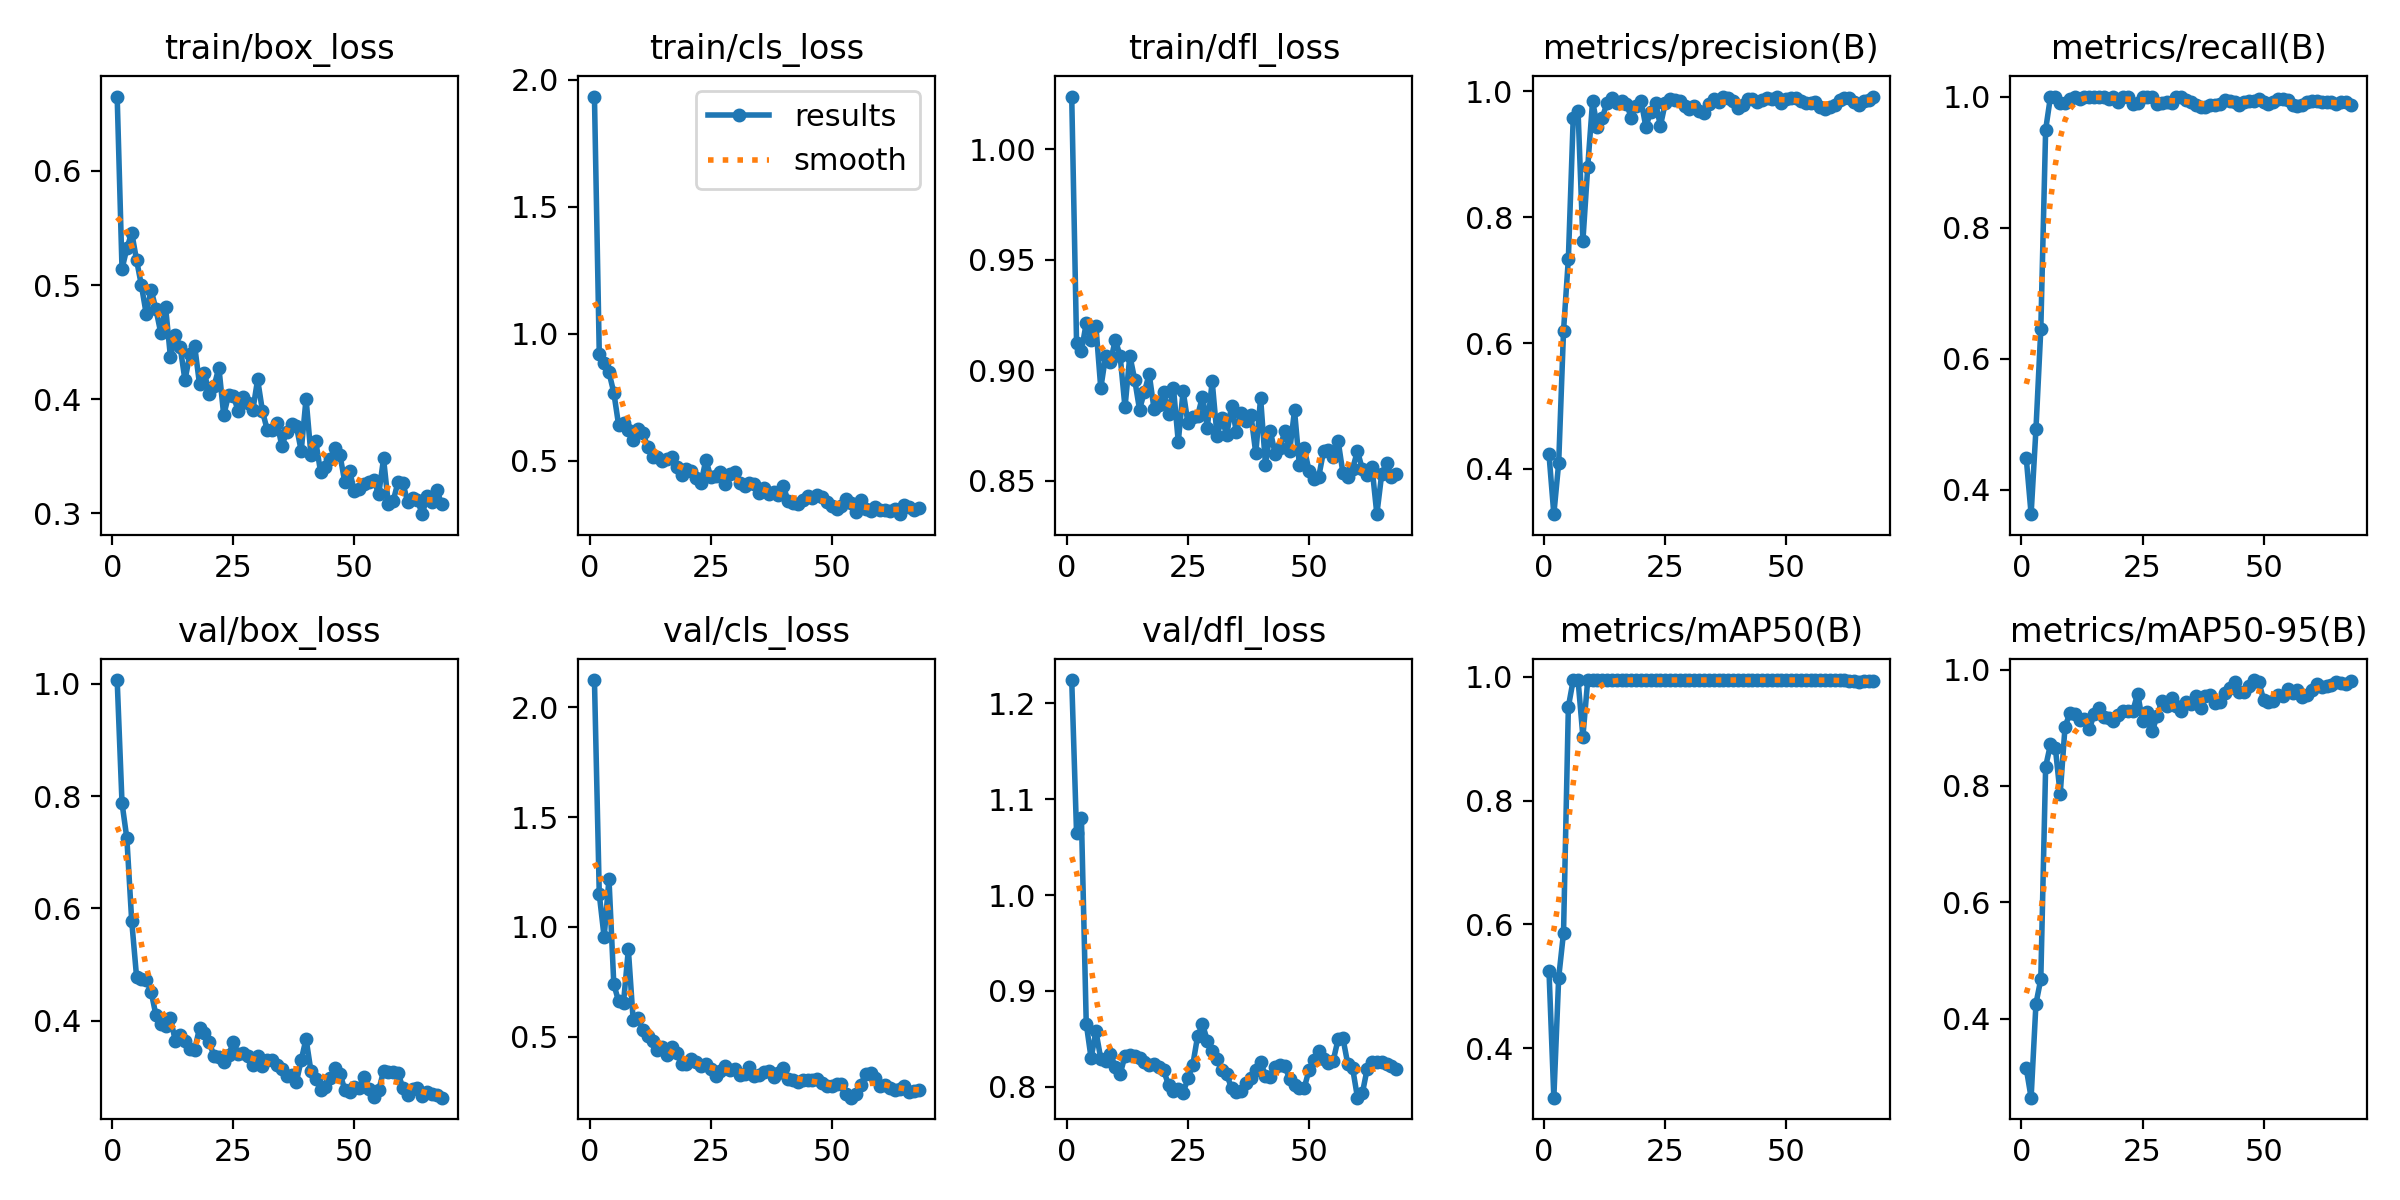


Confusion Matrix:


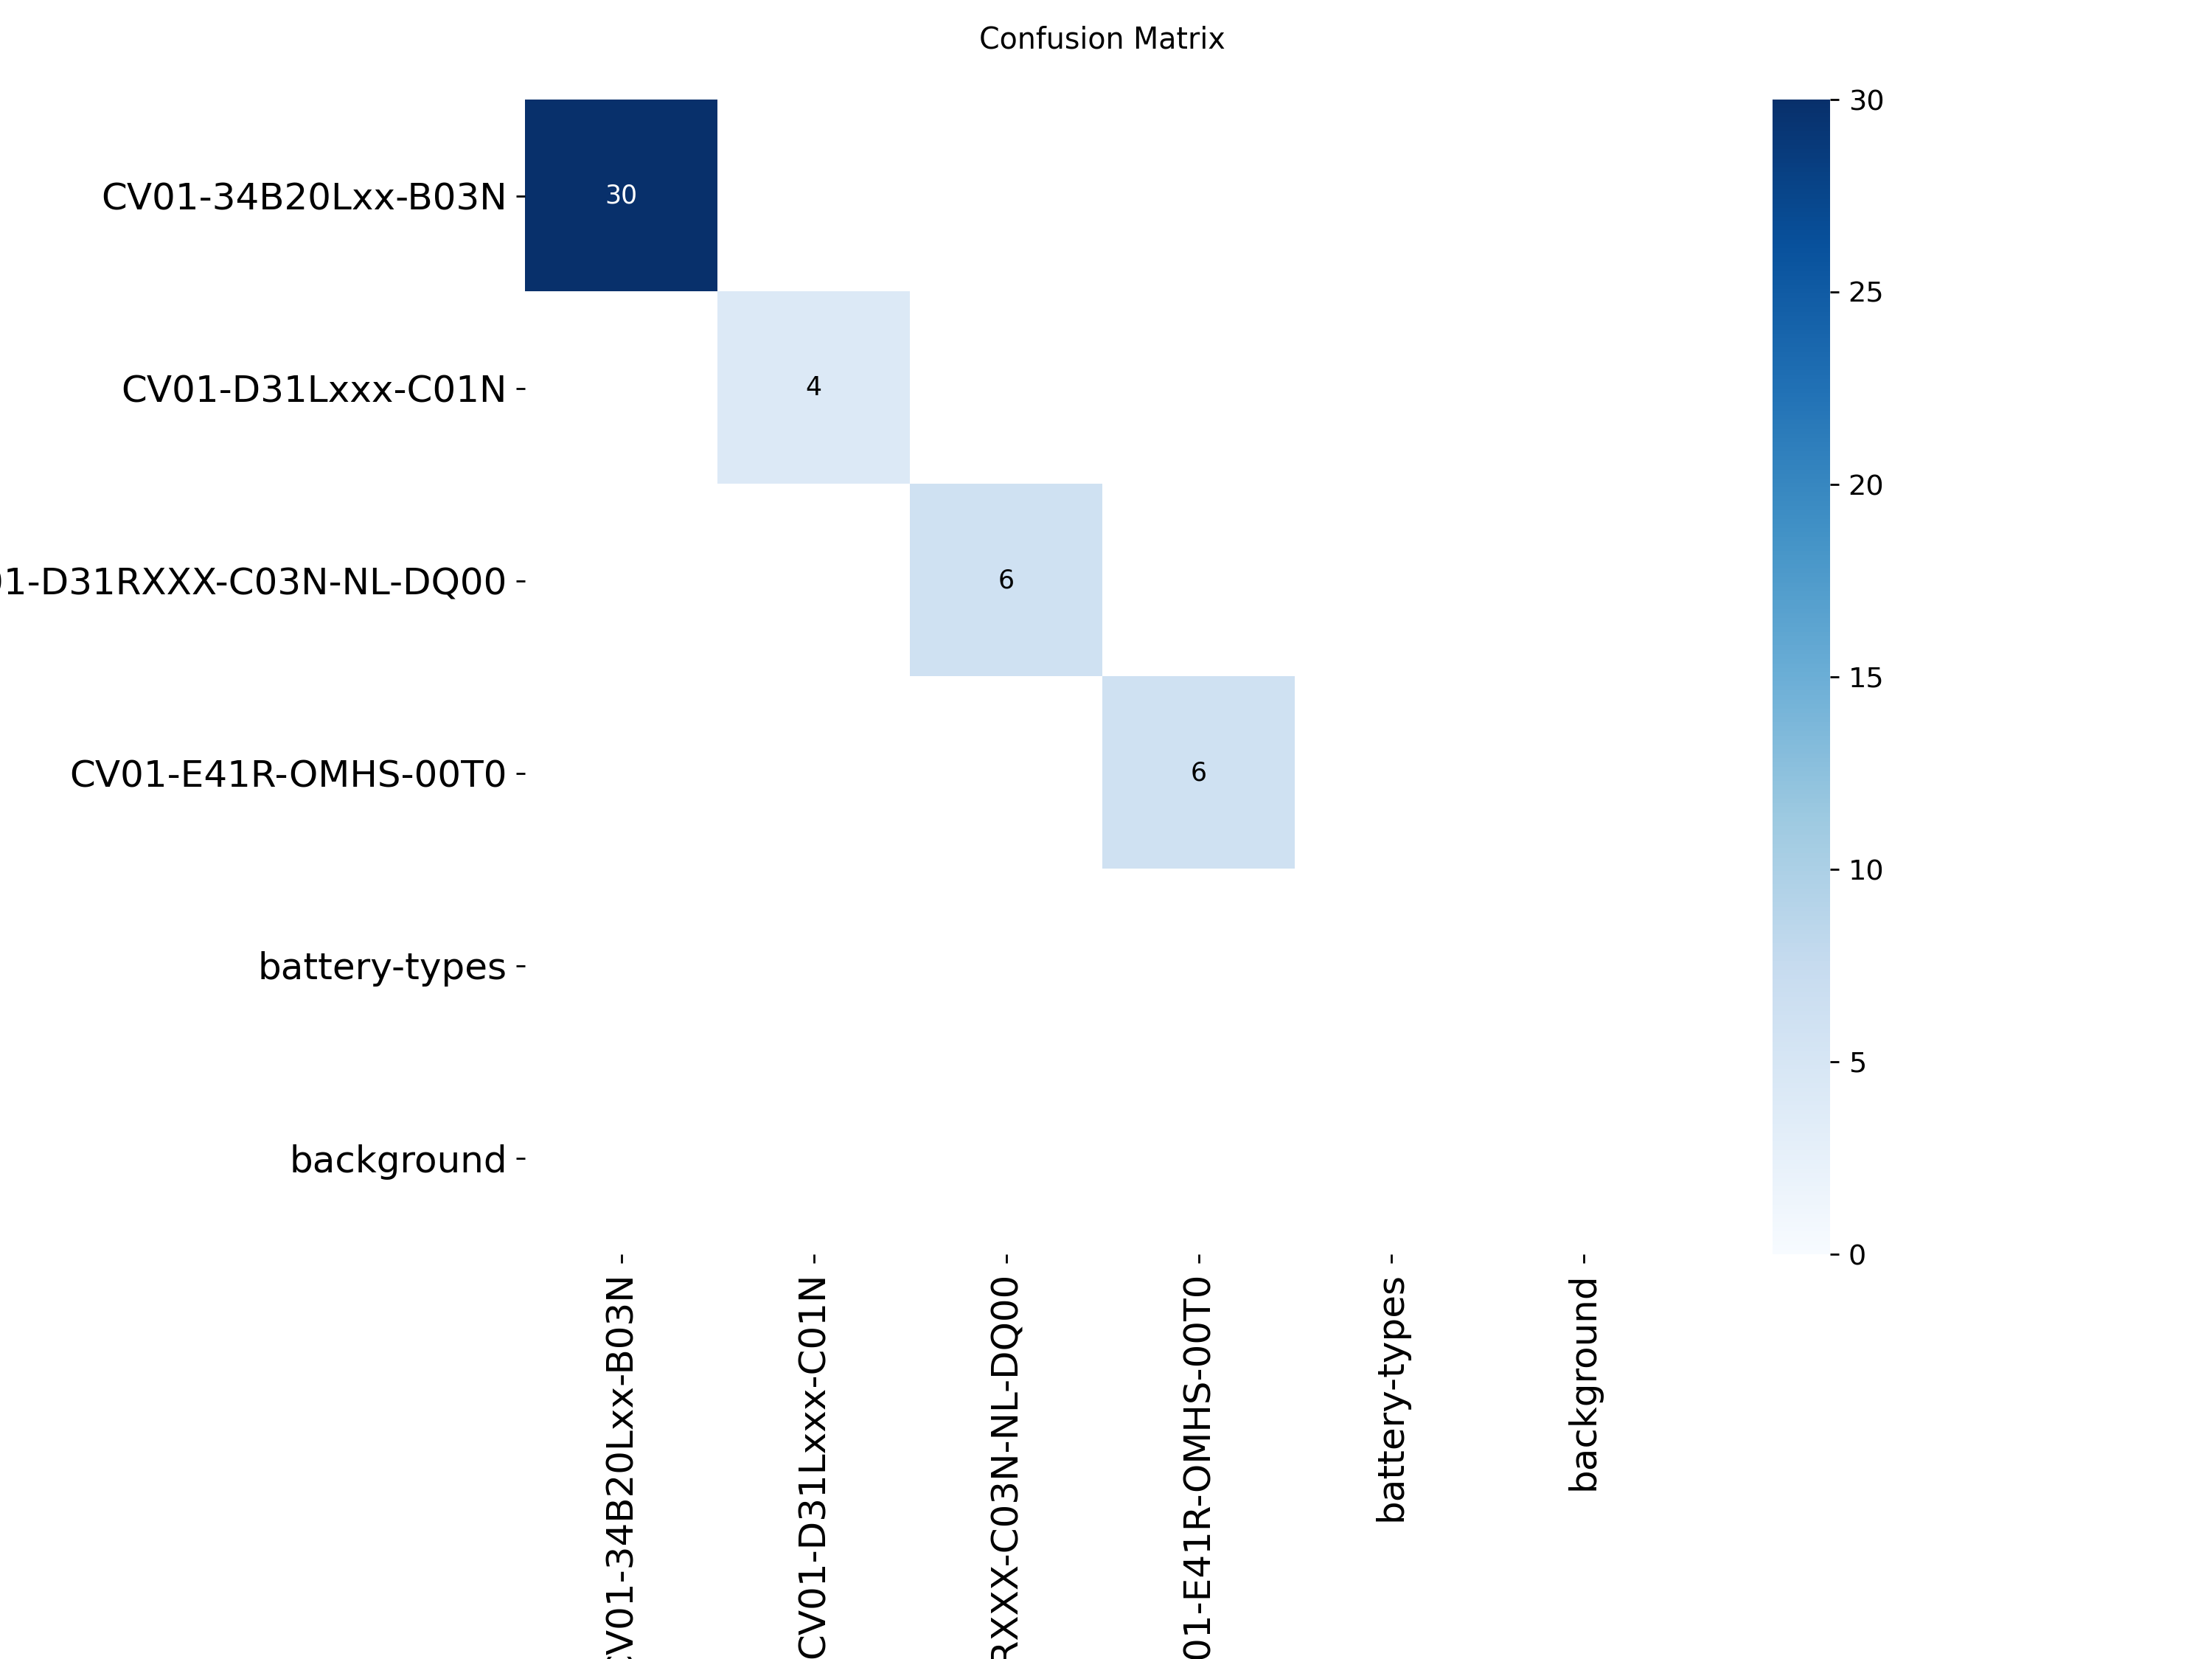

In [15]:
base_path  = Path(r"C:\Users\KAKA\repos\companies\cbi\line-compvis\runs\detect")
run_dir    = Path(RUN_DIR)

# Show results chart (loss + metrics curves)
results_png = run_dir / "results.png"
if results_png.exists():
    print("Training Curves:")
    display(Image(str(results_png), width=900))
else:
    print(f"results.png not found at: {results_png}")

# Show confusion matrix
conf_matrix = run_dir / "confusion_matrix.png"
if conf_matrix.exists():
    print("\nConfusion Matrix:")
    display(Image(str(conf_matrix), width=700))
else:
    print(f"confusion_matrix.png not found at: {conf_matrix}")

## Run Inference on Test Image

Running inference on: IMG_20260121_105812_jpg.rf.6107c77c61997caf18d4b36e68e3b53c.jpg


image 1/1 C:\Users\KAKA\repos\companies\cbi\yolo-compvis-project\Battery-Type-Detection-1\test\images\IMG_20260121_105812_jpg.rf.6107c77c61997caf18d4b36e68e3b53c.jpg: 640x640 8 CV01-34B20Lxx-B03Ns, 24.7ms
Speed: 9.7ms preprocess, 24.7ms inference, 19.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to C:\Users\KAKA\repos\companies\cbi\line-compvis\runs\detect\battery_detection\sample_inference
Detected 8 object(s):
  → CV01-34B20Lxx-B03N  confidence: 98.69%
  → CV01-34B20Lxx-B03N  confidence: 98.45%
  → CV01-34B20Lxx-B03N  confidence: 98.40%
  → CV01-34B20Lxx-B03N  confidence: 98.38%
  → CV01-34B20Lxx-B03N  confidence: 98.30%
  → CV01-34B20Lxx-B03N  confidence: 98.12%
  → CV01-34B20Lxx-B03N  confidence: 97.62%
  → CV01-34B20Lxx-B03N  confidence: 97.44%


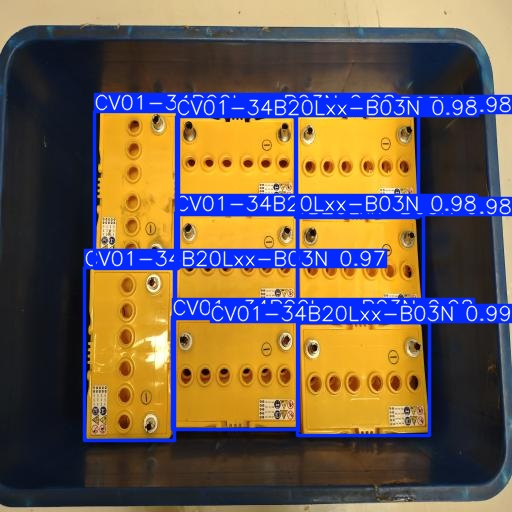

In [17]:
from IPython.display import Image, display

base_path    = Path(r"C:\Users\KAKA\repos\companies\cbi\line-compvis\runs\detect")

# Auto-pick first test image
test_img_dir = DATASET_PATH / "test" / "images"
test_images  = list(test_img_dir.glob("*.jpg")) + list(test_img_dir.glob("*.png"))

if test_images:
    sample_img = test_images[0]
    print(f"Running inference on: {sample_img.name}\n")

    predictions = model_best.predict(
        source   = str(sample_img),
        conf     = 0.5,
        save     = True,
        project  = os.path.join(PROJECT_DIR, PROJECT_NAME),
        name     = "sample_inference",
        exist_ok = True,
    )

    # Print detections
    for r in predictions:
        print(f"Detected {len(r.boxes)} object(s):")
        for box in r.boxes:
            cls_id   = int(box.cls[0])
            cls_name = data_config['names'][cls_id]
            conf     = float(box.conf[0])
            print(f"  → {cls_name:15s}  confidence: {conf:.2%}")

    # Display the annotated image
    saved_img = list((base_path / PROJECT_NAME / "sample_inference").glob("*.jpg"))
    if saved_img:
        display(Image(str(saved_img[0]), width=640))
    else:
        print(f"No saved image found at: {base_path / PROJECT_NAME / 'sample_inference'}")
else:
    print(f"No test images found at: {test_img_dir}")

## Summary

In [18]:
print("── Output Files ────────────────────────────────────────")
print(f"  Best weights : {best_weights.resolve()}")
print(f"  Training dir : {(Path(PROJECT_NAME) / RUN_NAME).resolve()}")
print()
print("── Quick Inference Snippets ────────────────────────────")
print("  # Single image")
print(f"  model = YOLO('{best_weights}')")
print("  model.predict('your_image.jpg', conf=0.5, save=True)")
print()
print("  # Live webcam")
print("  model.predict(source=0, show=True, conf=0.5)")
print("────────────────────────────────────────────────────────")

── Output Files ────────────────────────────────────────
  Best weights : C:\Users\KAKA\repos\companies\cbi\line-compvis\runs\detect\battery_detection\run1\weights\best.pt
  Training dir : C:\Users\KAKA\repos\companies\cbi\yolo-compvis-project\battery_detection\run1

── Quick Inference Snippets ────────────────────────────
  # Single image
  model = YOLO('C:\Users\KAKA\repos\companies\cbi\line-compvis\runs\detect\battery_detection\run1\weights\best.pt')
  model.predict('your_image.jpg', conf=0.5, save=True)

  # Live webcam
  model.predict(source=0, show=True, conf=0.5)
────────────────────────────────────────────────────────
